In [85]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [54]:
df = yf.download('BTC-USD', period='max',interval='1m', multi_level_index=False,)
df= df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


,Datetime,Close,High,Low,Open,Volume
0,2026-03-22 20:18:00+00:00,68363.617188,68363.617188,68363.617188,68363.617188,0
1,2026-03-22 20:19:00+00:00,68378.484375,68378.484375,68378.484375,68378.484375,51783680
2,2026-03-22 20:21:00+00:00,68425.359375,68425.359375,68425.359375,68425.359375,2775040
3,2026-03-22 20:22:00+00:00,68489.187500,68489.187500,68489.187500,68489.187500,0
4,2026-03-22 20:24:00+00:00,68418.031250,68418.031250,68418.031250,68418.031250,3289088
...,...,...,...,...,...,...
10521,2026-03-30 20:09:00+00:00,66550.382812,66550.382812,66550.382812,66550.382812,3559424
10522,2026-03-30 20:10:00+00:00,66572.304688,66572.304688,66572.304688,66572.304688,91090944
10523,2026-03-30 20:11:00+00:00,66588.406250,66588.406250,66588.406250,66588.406250,2625536
10524,2026-03-30 20:12:00+00:00,66583.789062,66583.789062,66583.789062,66583.789062,0


In [55]:
df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)

In [56]:
df.set_index("Datetime", inplace=True)
df = df.sort_index()

In [57]:
df.head()

,Close,High,Low,Open,Volume
Datetime,,,,,
2026-03-22 20:18:00,68363.617188,68363.617188,68363.617188,68363.617188,0
2026-03-22 20:19:00,68378.484375,68378.484375,68378.484375,68378.484375,51783680
2026-03-22 20:21:00,68425.359375,68425.359375,68425.359375,68425.359375,2775040
2026-03-22 20:22:00,68489.187500,68489.187500,68489.187500,68489.187500,0
2026-03-22 20:24:00,68418.031250,68418.031250,68418.031250,68418.031250,3289088


In [59]:
# Indicators
df['ema10'] = df.Close.ewm(min_periods=10, span=10).mean()
df['ema12'] = df.Close.ewm(min_periods=12, span=12).mean()
df['ema20'] = df.Close.ewm(min_periods=20, span=20).mean()
df['ema26'] = df.Close.ewm(min_periods=26, span=26).mean()
df['ema50'] = df.Close.ewm(min_periods=50, span=50).mean()
df['ema200'] = df.Close.ewm(min_periods=200, span=200).mean()
df['MACD'] = df['ema26'] - df['ema12']
df['MACD_signal']=df.MACD.ewm(min_periods=9, span=9).mean()

In [60]:
df=df.dropna()

In [22]:
train, test = df[:-60], df[-60:]

In [61]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

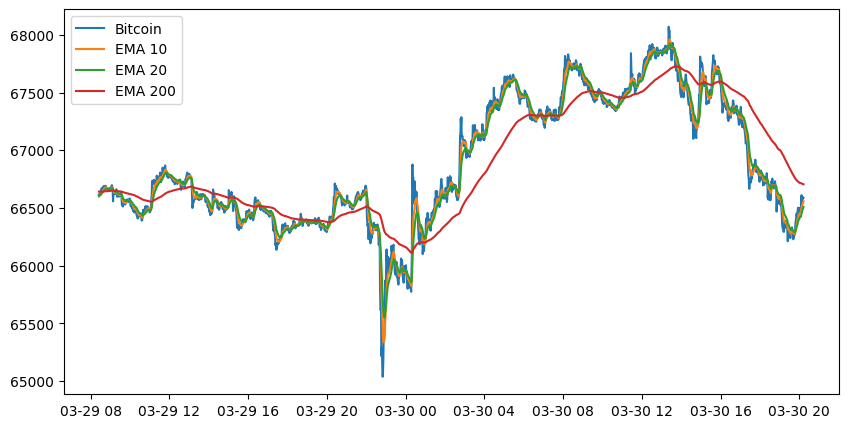

In [63]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test['Close'], label= 'Bitcoin')
plt.plot(test.index, test['ema10'], label= 'EMA 10')
plt.plot(test.index, test['ema20'], label= 'EMA 20')
plt.plot(test.index, test['ema200'], label= 'EMA 200')
plt.legend()
plt.show()

In [64]:
# target feature
target='Close'

In [65]:
# exogenous variables
exogenous=['ema10','ema20','ema12','ema26','ema50','ema200','MACD','MACD_signal']

In [66]:
# function to make lag features

def make_features(data):
    for lag in range(1,31):
        data[f'{target}_lag{lag}'] = data[target].shift(lag)
    #exogenous lags
    for col in exogenous:
        for lag in range(1,31):
            data[f'{col}_lag{lag}']=data[col].shift(lag)
    return data

In [68]:
train=make_features(train).dropna()
test=make_features(test).dropna()

In [69]:
# function to add features
features= [c for c in train.columns if c != target]

In [70]:
#creating x_train, y_train,x_test,y_test
X_train, y_train = train[features],train[target]
X_test, y_test = test[features], test[target]

In [71]:
#model
model = XGBRegressor()

In [72]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
pred = model.predict(X_test)

In [75]:
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(test['Close'], pred))
mae = mean_absolute_error(test['Close'], pred)
r2 = r2_score(test['Close'], pred)
mape = mean_absolute_percentage_error(test['Close'], pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:4f}")

RMSE: 97.3917
MAE: 51.4430
R² Score: 0.9687
MAPE: 0.000764


In [77]:
#Overffitig check
p_train = model.predict(X_train)
p_test = model.predict(X_test)
r2_train = r2_score(train['Close'],p_train)
r2_test = r2_score(test['Close'],p_test)

print(f"Train R2: {r2_train}")
print(f"Test R2: {r2_test}")

Train R2: 0.9999942329041221
Test R2: 0.9687169859212709


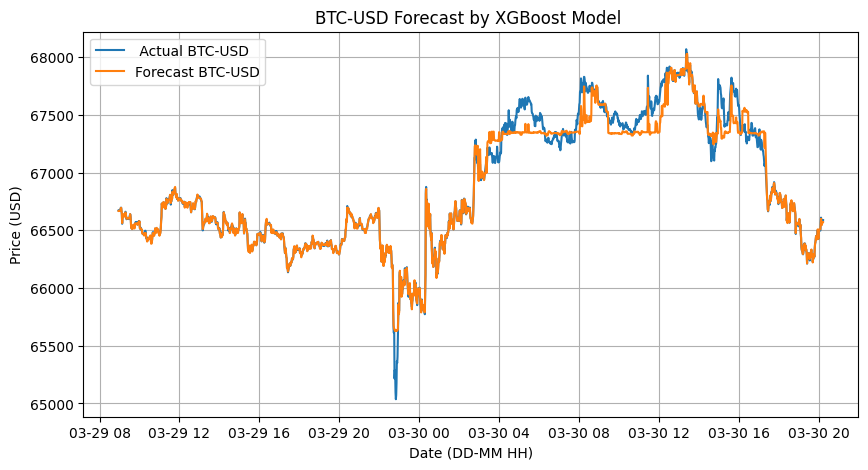

In [81]:
plt.figure(figsize= (10,5))
plt.plot(test.index, test['Close'], label=' Actual BTC-USD')
plt.plot(test.index, pred, label = 'Forecast BTC-USD')
plt.title('BTC-USD Forecast by XGBoost Model ')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()

<Axes: >

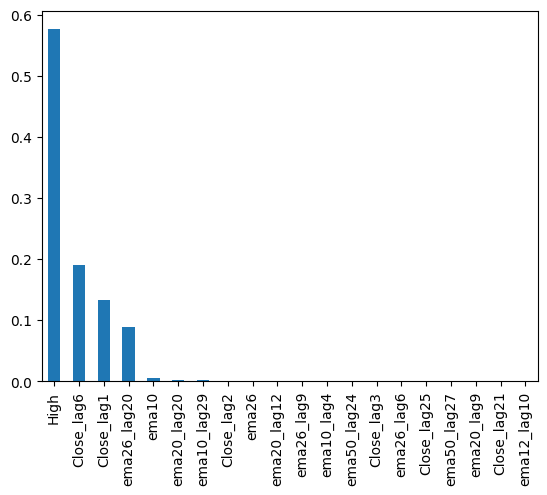

In [84]:
#feature importcance
importance= model.feature_importances_
f_imp =pd.Series(importance, index= X_train.columns).sort_values(ascending=False)
f_imp.head(20).plot(kind='bar')

Text(0.5, 1.0, 'Distribution of residuals')

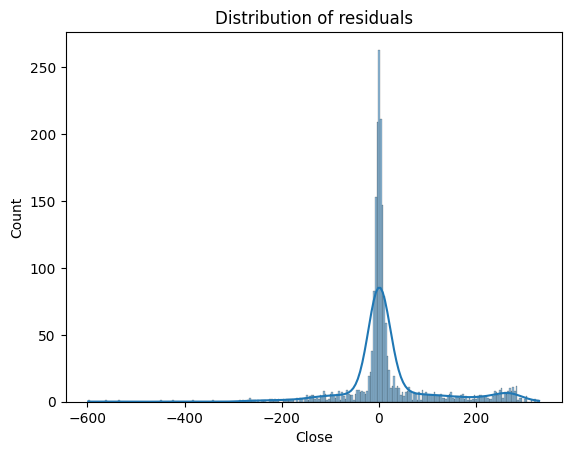

In [87]:
#residuals
residuals= y_test - pred
sns.histplot(residuals, kde=True)
plt.title('Distribution of residuals')

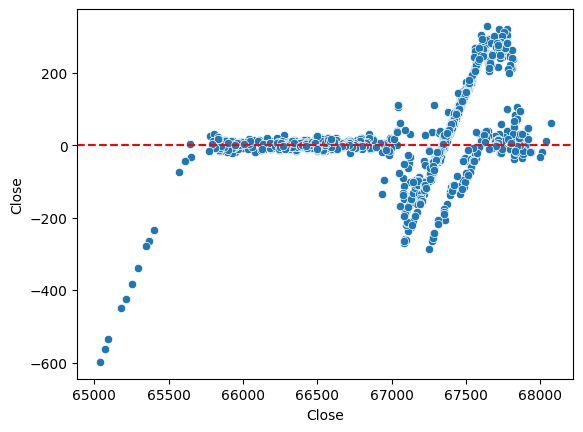

In [90]:
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0,color='red', linestyle='--')
plt.show()

In [79]:
test.tail(1)

,Close,High,Low,Open,Volume,ema10,ema12,ema20,ema26,ema50,...,MACD_signal_lag21,MACD_signal_lag22,MACD_signal_lag23,MACD_signal_lag24,MACD_signal_lag25,MACD_signal_lag26,MACD_signal_lag27,MACD_signal_lag28,MACD_signal_lag29,MACD_signal_lag30
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-03-30 20:13:00,66588.335938,66588.335938,66588.335938,66588.335938,18087936,66556.610236,66546.691836,66509.02472,66486.964394,66453.136234,...,22.581614,26.407657,29.005097,30.4737,32.048342,33.415514,34.279069,35.371397,36.719628,39.236547


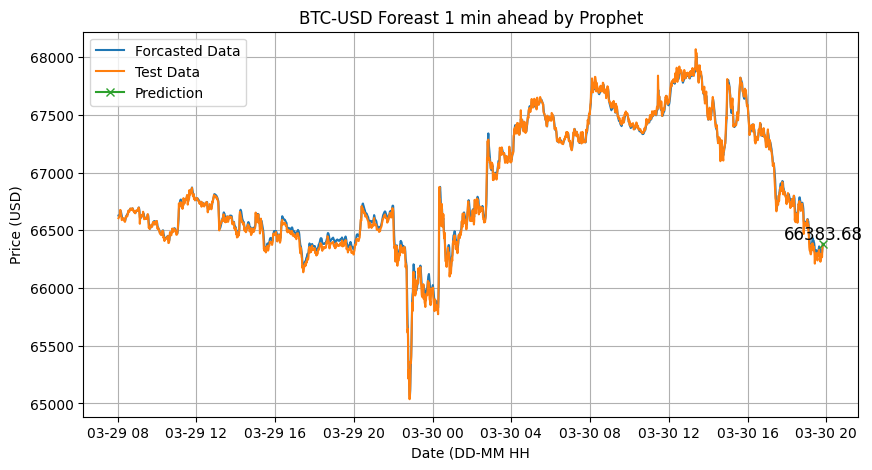

In [39]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', marker='x',)
#plt.axvline(pd.Timestamp('2026-03-04'), color='r', linestyle='--') 
for index, row in forecast.iterrows():
    plt.text(row['ds'], row['yhat'], f"{row['yhat']:.2f}", color='black', fontsize=12, ha='center', va='bottom')
plt.title('BTC-USD Foreast 1 min ahead by Prophet')
plt.xlabel('Date (DD-MM HH')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()